# 📊 Gemastik 2026: Dataset Exploratory Data Analysis (EDA) & 5-Fold Stratified GroupKFold Generator
### 🛡️ Pre-Split Dataset Profiling & Zero-Leakage K-Fold Splitting

This notebook performs two key functions:
1. 🔍 **Pre-Split Dataset EDA:** Comprehensive profiling of raw videos before splitting (file counts, class balance, extensions, resolution, FPS, video duration, and audio track availability).
2. 🛡️ **5-Fold Stratified GroupKFold Splitting:** Generates and exports **`kfold_splits.json`** to Google Drive (`/content/drive/MyDrive/Gemastik26/kfold_splits.json`), ensuring zero video-level leakage and uniform class distributions.

## 1. Setup Environment & Mount Google Drive

In [1]:
import os
import glob
import zipfile
import json
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import StratifiedGroupKFold

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("ℹ️ Local environment detected.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Path Configurations & Smart Dataset Unzipping

In [2]:
DRIVE_DATASET_DIR = "/content/drive/MyDrive/Gemastik26/Dataset Indonesia"
KFOLD_SPLIT_FILE = "/content/drive/MyDrive/Gemastik26/kfold_splits.json"
LOCAL_RAW_DIR = "/content/dataset_raw"
CLASSES = ["Real", "AI"]  # 0: Real, 1: AI
N_SPLITS = 5

ZIP_PATHS = {
    "Real": os.path.join(DRIVE_DATASET_DIR, "Real", "train.zip"),
    "AI": os.path.join(DRIVE_DATASET_DIR, "AI", "trainAI.zip")
}

def unzip_file(zip_path, extract_to):
    if not os.path.exists(zip_path):
        print(f"⚠️ Warning: Zip file not found at {zip_path}")
        return False
    print(f"📦 Unzipping {zip_path} -> {extract_to} ...")
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"✅ Unzipped successfully to {extract_to}")
    return True

for cls in CLASSES:
    extract_target = os.path.join(LOCAL_RAW_DIR, cls)
    zip_p = ZIP_PATHS.get(cls, "")
    if os.path.exists(extract_target) and len(os.listdir(extract_target)) > 0:
        print(f"⏭️ Target directory '{extract_target}' already exists. Skipping unzip.")
    else:
        unzip_file(zip_p, extract_target)

print("✅ Video archives unzipped and ready!")

⏭️ Target directory '/content/dataset_raw/Real' already exists. Skipping unzip.
⏭️ Target directory '/content/dataset_raw/AI' already exists. Skipping unzip.
✅ Video archives unzipped and ready!


## 3. Pre-Split Dataset Exploratory Data Analysis (EDA)

🔍 Collecting metadata for all raw video files before splitting ...


Profiling [Real]:   1%|          | 7/654 [00:00<00:09, 66.71it/s]

Profiling [AI]: 100%|██████████| 413/413 [00:03<00:00, 112.68it/s]

📊 PRE-SPLIT DATASET SUMMARY (RAW VIDEOS)
Total Unique Video Stems: 1067
--- Class Distribution ---
class
Real    654
AI      413
Name: count, dtype: int64
--- Summary Statistics by Class ---


class                        AI         Real
duration_sec count   413.000000   654.000000
             mean     18.677966    77.254939
             std      49.333841    71.645396
             min       6.040000     3.270000
             25%       8.770000    39.235000
             50%      10.040000    61.230000
             75%      16.000000    95.785000
             max     962.000000   896.700000
fps          count   413.000000   654.000000
             mean     26.679492    29.025199
             std       3.072773     2.067406
             min      13.000000    22.010000
             25%      24.000000    30.000000
             50%      24.000000    30.000000
             75%      30.000000    30.000000
             max      30.000000    30.000000
width        count   413.000000   654.000000
             mean    507.641646   736.299694
             std     183.620724   117.061451
             min     288.000000   356.000000
             25%     360.000000   720.000000
             50%     360.000000   720.000000
             75%     720.000000   720.000000
             max    1080.000000  1280.000000
height       count   413.000000   654.000000
             mean    898.237288  1207.464832
             std     325.965261   221.670978
             min     430.000000   358.000000
             25%     640.000000  1280.000000
             50%     640.000000  1280.000000
             75%    1280.000000  1280.000000
             max    1920.000000  1920.000000

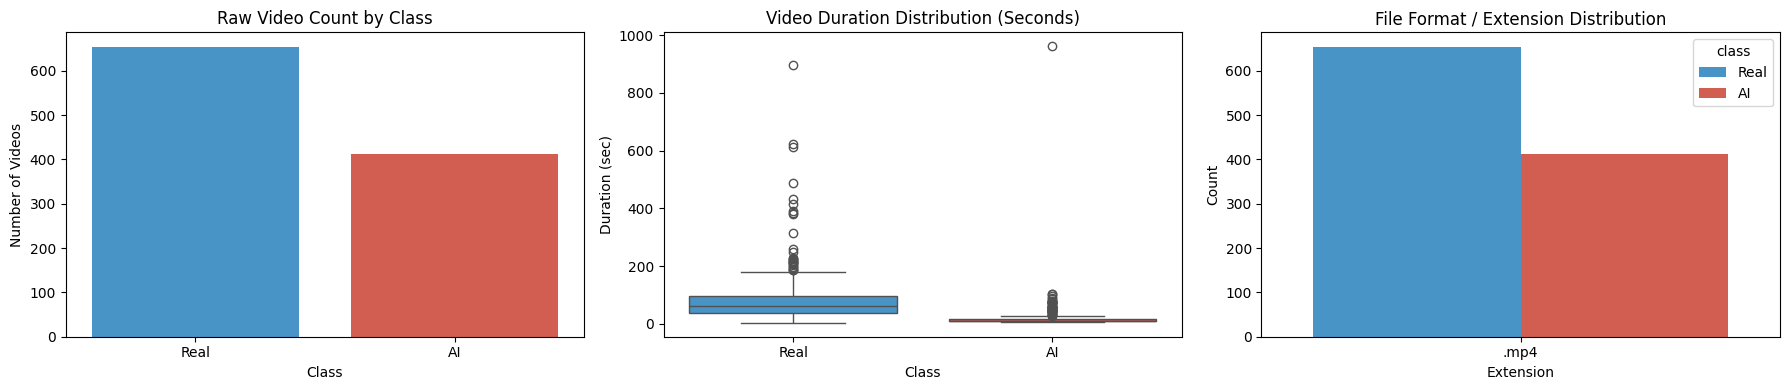

In [3]:
raw_video_records = []
video_extensions = ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV")

print("🔍 Collecting metadata for all raw video files before splitting ...")
for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(LOCAL_RAW_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    vfiles = []
    for ext in video_extensions:
        vfiles.extend(glob.glob(os.path.join(cls_dir, "**", ext), recursive=True))
    
    for vf in tqdm(vfiles, desc=f"Profiling [{cls}]"):
        stem = Path(vf).stem
        ext = Path(vf).suffix.lower()
        cap = cv2.VideoCapture(vf)
        if not cap.isOpened():
            continue
        
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        duration = frame_count / fps if fps > 0 else 0.0
        cap.release()
        
        raw_video_records.append({
            "video_path": vf,
            "stem": stem,
            "label": label_idx,
            "class": cls,
            "extension": ext,
            "width": width,
            "height": height,
            "fps": round(fps, 2),
            "duration_sec": round(duration, 2),
            "est_1fps_frames": min(30, max(1, int(round(duration))))
        })

df_raw_eda = pd.DataFrame(raw_video_records).drop_duplicates(subset=["stem"]).reset_index(drop=True)

print("========================================================")
print("📊 PRE-SPLIT DATASET SUMMARY (RAW VIDEOS)")
print("========================================================")
print(f"Total Unique Video Stems: {len(df_raw_eda)}")
print("--- Class Distribution ---")
print(df_raw_eda["class"].value_counts())

print("--- Summary Statistics by Class ---")
display(df_raw_eda.groupby("class")[["duration_sec", "fps", "width", "height"]].describe().T)

# Visual Pre-Split EDA Plots (Fixed Seaborn v0.14+ syntax)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df_raw_eda, x="class", hue="class", legend=False, palette=["#3498db", "#e74c3c"], ax=axes[0])
axes[0].set_title("Raw Video Count by Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Videos")

sns.boxplot(data=df_raw_eda, x="class", y="duration_sec", hue="class", legend=False, palette=["#3498db", "#e74c3c"], ax=axes[1])
axes[1].set_title("Video Duration Distribution (Seconds)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Duration (sec)")

sns.countplot(data=df_raw_eda, x="extension", hue="class", palette=["#3498db", "#e74c3c"], ax=axes[2])
axes[2].set_title("File Format / Extension Distribution")
axes[2].set_xlabel("Extension")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 4. Run 5-Fold Stratified GroupKFold Splitting & Leakage Audit

In [4]:
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

df_videos = df_raw_eda.copy()
total_main_videos = len(df_videos)
main_real_cnt = (df_videos["label"] == 0).sum()
main_ai_cnt = (df_videos["label"] == 1).sum()
main_real_pct = (main_real_cnt / total_main_videos) * 100
main_ai_pct = (main_ai_cnt / total_main_videos) * 100

X = df_videos["stem"].values
y = df_videos["label"].values
groups = df_videos["stem"].values

kfold_splits = {}
fold_eda_records = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups), start=1):
    train_stems = list(set(df_videos.iloc[train_idx]["stem"].values))
    val_stems = list(set(df_videos.iloc[val_idx]["stem"].values))
    
    # Leakage Audit: Intersection must be exactly zero
    overlap = set(train_stems).intersection(set(val_stems))
    assert len(overlap) == 0, f"❌ Error in Fold {fold}: Data leakage detected! Overlap: {overlap}"
    
    kfold_splits[f"fold_{fold}"] = {
        "train_stems": train_stems,
        "val_stems": val_stems
    }
    
    val_df = df_videos.iloc[val_idx]
    real_val_cnt = (val_df["label"] == 0).sum()
    ai_val_cnt = (val_df["label"] == 1).sum()
    tot_val = len(val_df)
    real_val_pct = (real_val_cnt / tot_val) * 100 if tot_val > 0 else 0
    ai_val_pct = (ai_val_cnt / tot_val) * 100 if tot_val > 0 else 0
    
    train_df = df_videos.iloc[train_idx]
    real_tr_cnt = (train_df["label"] == 0).sum()
    ai_tr_cnt = (train_df["label"] == 1).sum()
    tot_tr = len(train_df)
    
    fold_eda_records.append({
        "Fold": f"Fold {fold}",
        "Train Videos": tot_tr,
        "Train Real %": f"{(real_tr_cnt/tot_tr)*100:.1f}%",
        "Train AI %": f"{(ai_tr_cnt/tot_tr)*100:.1f}%",
        "Val Videos": tot_val,
        "Val Real": real_val_cnt,
        "Val AI": ai_val_cnt,
        "Val Real %": f"{real_val_pct:.1f}%",
        "Val AI %": f"{ai_val_pct:.1f}%",
        "Leakage Overlap": len(overlap)
    })

df_fold_summary = pd.DataFrame(fold_eda_records)
print("========================================================")
print("📊 5-FOLD STRATIFIED GROUPKFOLD SUMMARY & LEAKAGE AUDIT")
print("========================================================")
display(df_fold_summary)

📊 5-FOLD STRATIFIED GROUPKFOLD SUMMARY & LEAKAGE AUDIT


,Fold,Train Videos,Train Real %,Train AI %,Val Videos,Val Real,Val AI,Val Real %,Val AI %,Leakage Overlap
0,Fold 1,853,61.0%,39.0%,214,134,80,62.6%,37.4%,0
1,Fold 2,854,60.9%,39.1%,213,134,79,62.9%,37.1%,0
2,Fold 3,853,62.1%,37.9%,214,124,90,57.9%,42.1%,0
3,Fold 4,854,61.9%,38.1%,213,125,88,58.7%,41.3%,0
4,Fold 5,854,60.5%,39.5%,213,137,76,64.3%,35.7%,0


## 5. Main Dataset Distribution Comparison & Visual Fold EDA

📈 CLASS DISTRIBUTION COMPARISON: PRE-SPLIT VS KFOLD VALIDATIONS


,Subset,Total Videos,Real Count,AI Count,Real %,AI %
0,Main Dataset (Pre-Split Overall),1067,654,413,61.29%,38.71%
1,Validation Fold 1,214,134,80,62.6%,37.4%
2,Validation Fold 2,213,134,79,62.9%,37.1%
3,Validation Fold 3,214,124,90,57.9%,42.1%
4,Validation Fold 4,213,125,88,58.7%,41.3%
5,Validation Fold 5,213,137,76,64.3%,35.7%


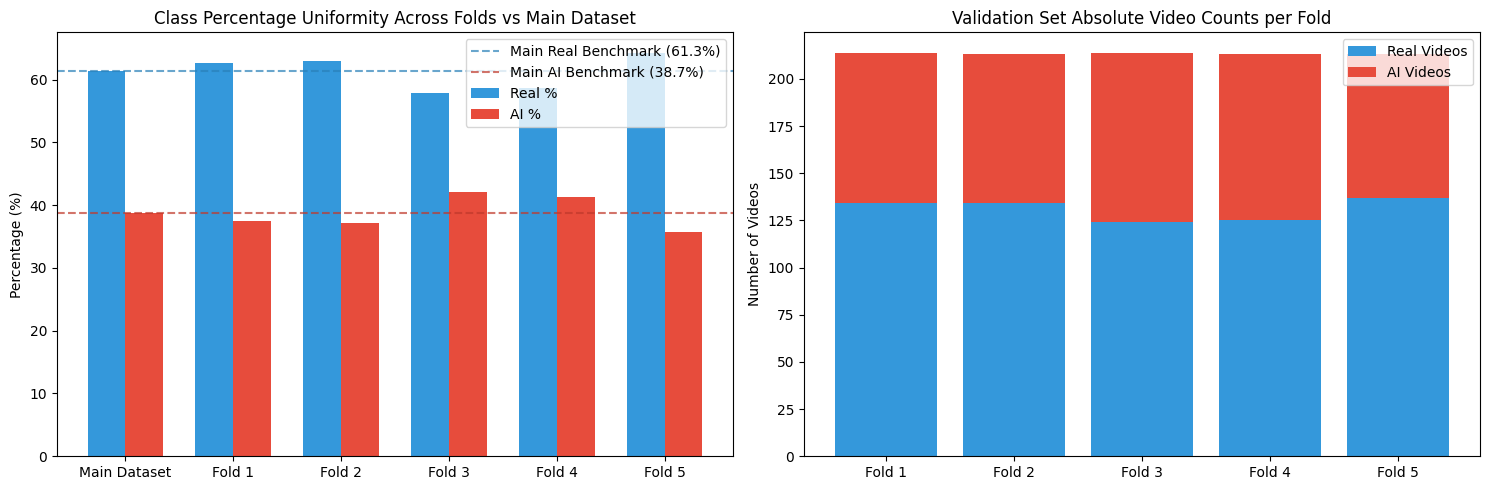

In [5]:
dist_comparison = []
dist_comparison.append({
    "Subset": "Main Dataset (Pre-Split Overall)",
    "Total Videos": total_main_videos,
    "Real Count": main_real_cnt,
    "AI Count": main_ai_cnt,
    "Real %": f"{main_real_pct:.2f}%",
    "AI %": f"{main_ai_pct:.2f}%"
})

for idx, row in df_fold_summary.iterrows():
    dist_comparison.append({
        "Subset": f"Validation {row['Fold']}",
        "Total Videos": row["Val Videos"],
        "Real Count": row["Val Real"],
        "AI Count": row["Val AI"],
        "Real %": row["Val Real %"],
        "AI %": row["Val AI %"]
    })

df_dist_comp = pd.DataFrame(dist_comparison)
print("===============================================================")
print("📈 CLASS DISTRIBUTION COMPARISON: PRE-SPLIT VS KFOLD VALIDATIONS")
print("===============================================================")
display(df_dist_comp)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

labels = ["Main Dataset"] + [f"Fold {i}" for i in range(1, 6)]
real_pcts = [main_real_pct] + [float(r["Val Real %"].replace("%", "")) for r in fold_eda_records]
ai_pcts = [main_ai_pct] + [float(r["Val AI %"].replace("%", "")) for r in fold_eda_records]

x = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, real_pcts, width, label="Real %", color="#3498db")
axes[0].bar(x + width/2, ai_pcts, width, label="AI %", color="#e74c3c")
axes[0].axhline(y=main_real_pct, color="#2980b9", linestyle="--", alpha=0.7, label=f"Main Real Benchmark ({main_real_pct:.1f}%)")
axes[0].axhline(y=main_ai_pct, color="#c0392b", linestyle="--", alpha=0.7, label=f"Main AI Benchmark ({main_ai_pct:.1f}%)")
axes[0].set_title("Class Percentage Uniformity Across Folds vs Main Dataset")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()

fold_names = [f"Fold {i}" for i in range(1, 6)]
real_counts = [r["Val Real"] for r in fold_eda_records]
ai_counts = [r["Val AI"] for r in fold_eda_records]

axes[1].bar(fold_names, real_counts, label="Real Videos", color="#3498db")
axes[1].bar(fold_names, ai_counts, bottom=real_counts, label="AI Videos", color="#e74c3c")
axes[1].set_title("Validation Set Absolute Video Counts per Fold")
axes[1].set_ylabel("Number of Videos")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Export `kfold_splits.json` to Google Drive

In [6]:
os.makedirs(os.path.dirname(KFOLD_SPLIT_FILE), exist_ok=True)

with open(KFOLD_SPLIT_FILE, "w", encoding="utf-8") as f:
    json.dump(kfold_splits, f, indent=2)

print("========================================================")
print(f"💾 SUCCESS: 5-Fold split file successfully saved to Drive:")
print(f"➡️ {KFOLD_SPLIT_FILE}")
print("========================================================")
print(f"   File size: {os.path.getsize(KFOLD_SPLIT_FILE)} bytes")
print(f"   Folds saved: {list(kfold_splits.keys())}")

💾 SUCCESS: 5-Fold split file successfully saved to Drive:
➡️ /content/drive/MyDrive/Gemastik26/kfold_splits.json
   File size: 96172 bytes
   Folds saved: ['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']
